# Question 1

In [ ]:
# ============================================================
#  Setup + Load splits
# ============================================================

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = "data/processed"
TRAIN_PATH = os.path.join(DATA_DIR, "train.csv")
DEV_PATH   = os.path.join(DATA_DIR, "dev.csv")
TEST_PATH  = os.path.join(DATA_DIR, "test.csv")

train_df = pd.read_csv(TRAIN_PATH)
dev_df   = pd.read_csv(DEV_PATH)
test_df  = pd.read_csv(TEST_PATH)

print("Train:", train_df.shape, "Dev:", dev_df.shape, "Test:", test_df.shape)
display(train_df.head(3))


def pick_col(df: pd.DataFrame, candidates):
    cols_lower = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in cols_lower:
            return cols_lower[cand.lower()]
    # fallback for partial match
    for c in df.columns:
        cl = c.lower()
        for cand in candidates:
            if cand.lower() in cl:
                return c
    raise KeyError(f"Could not find any of {candidates} in columns: {list(df.columns)}")

LABEL_COL  = pick_col(train_df, ["label", "stance", "sdqc", "gold", "class"])
SOURCE_COL = pick_col(train_df, ["source", "source_text", "source_tweet", "src", "rumour", "sourcepost"])
REPLY_COL  = pick_col(train_df, ["reply", "reply_text", "response", "text", "tweet", "comment_text"])

print("Using columns:")
print("  LABEL_COL :", LABEL_COL)
print("  SOURCE_COL:", SOURCE_COL)
print("  REPLY_COL :", REPLY_COL)

# Normalize labels
def normalize_label(x: str) -> str:
    x = str(x).strip()
    if x in {"S","D","Q","C"}:
        return x
    xl = x.lower()
    mapping = {
        "support": "S",
        "deny": "D",
        "denial": "D",
        "query": "Q",
        "comment": "C",
        "no_stance": "C",
        "nostance": "C",
        "nonstance": "C",
    }
    if xl in mapping:
        return mapping[xl]
    mapping_num = {"0":"S","1":"D","2":"Q","3":"C"}
    if xl in mapping_num:
        return mapping_num[xl]
    return x

for df in (train_df, dev_df, test_df):
    df[LABEL_COL] = df[LABEL_COL].apply(normalize_label)


def filter_sdqc(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df = df[df[LABEL_COL].isin(["S","D","Q","C"])].reset_index(drop=True)
    return df

train_df = filter_sdqc(train_df)
dev_df   = filter_sdqc(dev_df)
test_df  = filter_sdqc(test_df)

print("After filtering to {S,D,Q,C}:")
print("Train:", train_df.shape, "Dev:", dev_df.shape, "Test:", test_df.shape)
print("Label distribution (train):")
display(train_df[LABEL_COL].value_counts())


Train: (3569, 22) Dev: (950, 22) Test: (1049, 4)


,tweet_id,label,event,source_id,source_text,reply_text,reply_text_empty,source_text_empty,reply_text_norm,source_text_norm,...,reply_len_tok,source_len_tok,reply_len_char,source_len_char,stance,overlap_ratio,jaccard,src_covered,reply_word_types,source_word_types
0,501760642928635904,C,ferguson,500279160795721728,Question for #Ferguson police chief? If OFFICE...,@max843 @DanteB4u @Alasscan_ This shows Micha...,False,False,<USER> <USER> <USER> This shows Michael...,Question for #Ferguson police chief? If OFFICE...,...,27,30,105,140,0,0.153846,0.055556,0.080000,13.0,25.0
1,524971210275565568,C,ottawashooting,524964948683005952,#Ottawa police confirm to #CBCNews they are st...,@rikermacdaniels @CBCAlerts @CBCNews @JustinTr...,False,False,<USER> <USER> <USER> <USER> your radic...,#Ottawa police confirm to #CBCNews they are st...,...,26,27,118,139,0,0.071429,0.028571,0.045455,14.0,22.0
2,552836882770690049,C,charliehebdo,552833028201144320,URGENT: 3 gunmen involved in deadly attack on ...,@RT_com Just kill them.,False,False,<USER> Just kill them.,URGENT: 3 gunmen involved in deadly attack on ...,...,7,23,25,109,0,0.000000,0.000000,0.000000,4.0,14.0


Using columns:
  LABEL_COL : label
  SOURCE_COL: source_text
  REPLY_COL : reply_text
After filtering to {S,D,Q,C}:
Train: (3569, 22) Dev: (950, 22) Test: (1049, 4)
Label distribution (train):


label
C    2291
S     743
D     273
Q     262
Name: count, dtype: int64

In [ ]:
# ============================================================
# Tokenization and stopwords filtering
# ============================================================

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

URL_RE = re.compile(r"https?://\S+|www\.\S+")
MENTION_RE = re.compile(r"@\w+")
TOKEN_RE = re.compile(r"#\w+|[a-z]+(?:'[a-z]+)?|\d+(?:\.\d+)?", re.IGNORECASE)

# Stopwords
BASE_STOPWORDS = set(ENGLISH_STOP_WORDS)
TWITTER_STOPWORDS = {"rt", "amp", "@user", "user", "its", "it's"}
EXTRA_STOPWORDS = set()

KEEP_TOKENS = {
    "no", "not", "nor", "never", "n't",
    "why", "what", "who", "where", "when", "how"
}

STOPWORDS = (BASE_STOPWORDS | TWITTER_STOPWORDS | EXTRA_STOPWORDS) - KEEP_TOKENS

def normalize_text(s: str, replace_mentions=True) -> str:
    s = "" if pd.isna(s) else str(s)
    s = s.strip()
    s = URL_RE.sub(" ", s)
    if replace_mentions:
        s = MENTION_RE.sub(" @user ", s)
    s = s.lower()
    s = re.sub(r"\s+", " ", s).strip()
    return s

def tokenize(s: str) -> list[str]:
    s = normalize_text(s)
    toks = TOKEN_RE.findall(s)

    cleaned = []
    for t in toks:
        tl = t.lower()
        if tl in STOPWORDS:
            continue
        if len(tl) <= 1:
            continue
        cleaned.append(tl)
    return cleaned

sample = train_df.iloc[0]
print("REPLY:", sample[REPLY_COL])
print("TOKENS:", tokenize(sample[REPLY_COL])[:30])


REPLY: @max843 @DanteB4u @Alasscan_  This shows Michael paid for cigarillos. No robbery, no crime! Pls RT 
http://t.co/ZwYEcGvXya
TOKENS: ['shows', 'michael', 'paid', 'cigarillos', 'no', 'robbery', 'no', 'crime', 'pls']


## 1(a)

In [ ]:
# ============================================================
# Unigrams and Bigrams
# ============================================================

from sklearn.feature_extraction.text import CountVectorizer

def make_vectorizer(ngram_range=(1,1), min_df=2, max_df=0.95):

    return CountVectorizer(
        tokenizer=lambda s: tokenize(s),
        preprocessor=lambda s: s,
        token_pattern=None,
        lowercase=False,
        ngram_range=ngram_range,
        min_df=min_df,
        max_df=max_df,
    )

def top_ngrams_by_label(df: pd.DataFrame, text_col: str, label_col: str, labels=("S","D","Q","C"),
                        ngram_range=(1,1), top_k=20, min_df=2):
    vec = make_vectorizer(ngram_range=ngram_range, min_df=min_df)
    rows = []
    for lab in labels:
        sub = df[df[label_col] == lab]
        X = vec.fit_transform(sub[text_col].fillna("").astype(str))
        freqs = np.asarray(X.sum(axis=0)).ravel()
        vocab = np.array(vec.get_feature_names_out())
        top_idx = np.argsort(freqs)[::-1][:top_k]
        for rank, i in enumerate(top_idx, start=1):
            rows.append({
                "label": lab,
                "rank": rank,
                "ngram": vocab[i],
                "count": int(freqs[i]),
            })
    return pd.DataFrame(rows)

# Unigrams
top_uni = top_ngrams_by_label(train_df, REPLY_COL, LABEL_COL, ngram_range=(1,1), top_k=25, min_df=2)
display(top_uni)

# Bigrams
top_bi = top_ngrams_by_label(train_df, REPLY_COL, LABEL_COL, ngram_range=(2,2), top_k=25, min_df=2)
display(top_bi)

def show_top_table(df_top: pd.DataFrame, title: str):
    print("\n" + "="*len(title))
    print(title)
    print("="*len(title))
    for lab in ["S","D","Q","C"]:
        sub = df_top[df_top["label"] == lab].head(15)
        print(f"\nLabel {lab}:")
        display(sub[["rank","ngram","count"]])

show_top_table(top_uni, "Top UNIGRAMS in replies by label (train)")
show_top_table(top_bi,  "Top BIGRAMS in replies by label (train)")


,label,rank,ngram,count
0,S,1,police,97
1,S,2,hostages,87
2,S,3,paris,76
3,S,4,hostage,74
4,S,5,sydney,74
...,...,...,...,...
95,C,21,robbery,51
96,C,22,how,51
97,C,23,shooting,49
98,C,24,killed,48


,label,rank,ngram,count
0,S,1,sydney cafe,33
1,S,2,charlie hebdo,25
2,S,3,supermarket paris,25
3,S,4,french alps,21
4,S,5,thomas samson,19
...,...,...,...,...
95,C,21,cbd today,9
96,C,22,martin place,9
97,C,23,intros surge,9
98,C,24,sydney hostage,9



Top UNIGRAMS in replies by label (train)

Label S:


,rank,ngram,count
0,1,police,97
1,2,hostages,87
2,3,paris,76
3,4,hostage,74
4,5,sydney,74
5,6,breaking,55
6,7,cafe,54
7,8,#charliehebdo,54
8,9,#ferguson,50
9,10,#sydneysiege,42



Label D:


...

,rank,ngram,count
25,1,not isis,6
26,2,isis flag,5
27,3,that's not,5
28,4,islamic flag,5
29,5,parliament hill,4
30,6,did not,4
31,7,don't think,4
32,8,not islamic,4
33,9,not true,4
34,10,don't know,3



Label Q:


,rank,ngram,count
50,1,why did,5
51,2,sydney cafe,4
52,3,why not,3
53,4,how know,3
54,5,why does,3
55,6,looks like,3
56,7,isis flag,3
57,8,need wait,2
58,9,mike brown,2
59,10,michael brown,2



Label C:


,rank,ngram,count
75,1,parliament hill,25
76,2,kosher market,14
77,3,looks like,14
78,4,surge pricing,13
79,5,shots fired,13
80,6,hostage taking,13
81,7,shooting hostage,12
82,8,market paris,12
83,9,taking kosher,12
84,10,don't know,12


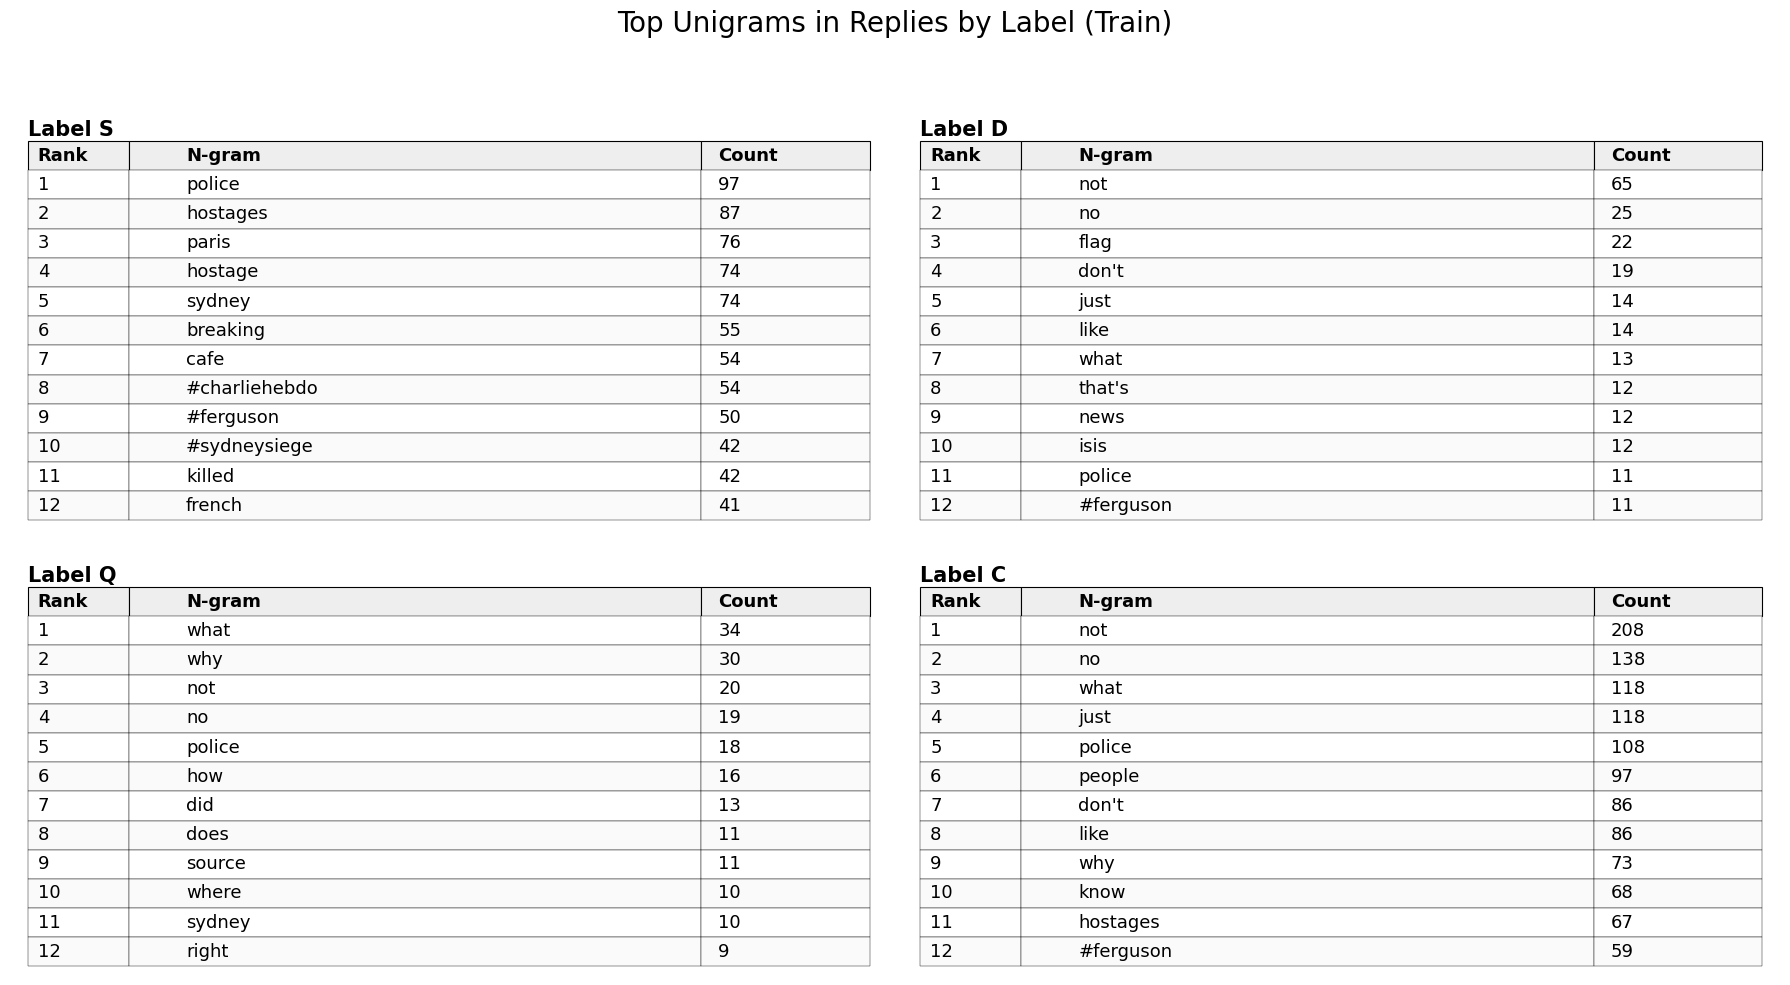

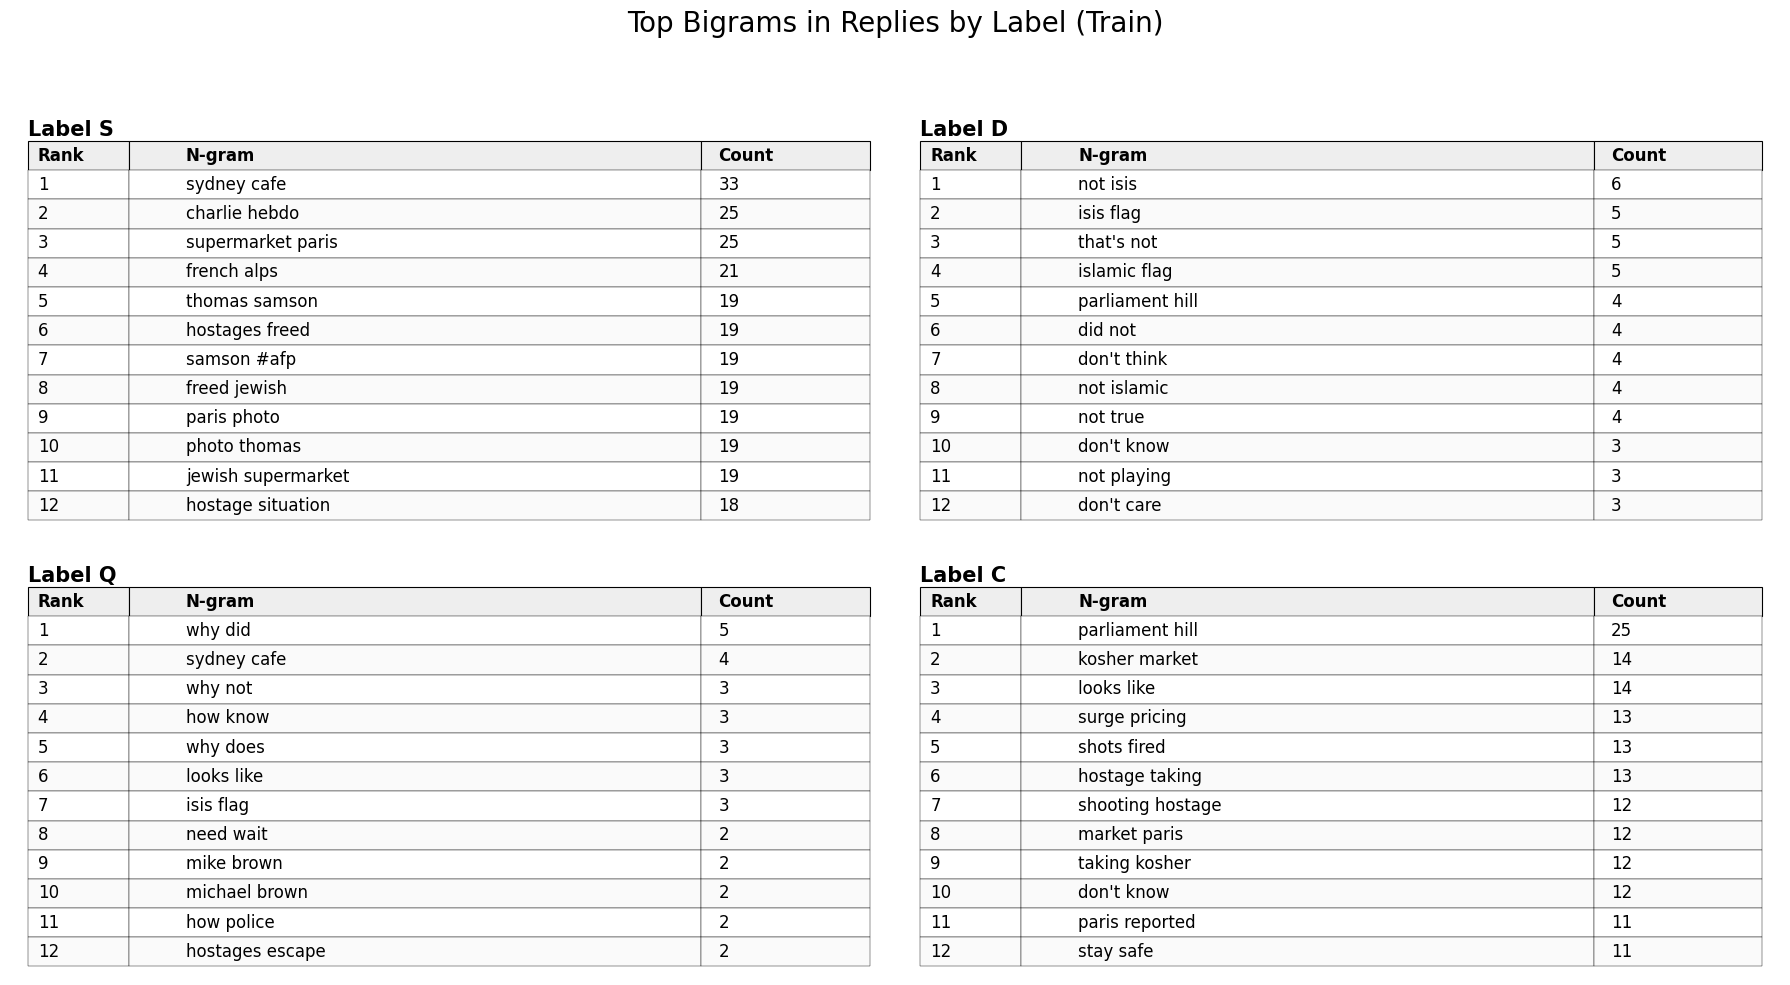

In [ ]:
# ============================================================
# image tables
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

def _table_for_label(df_top, lab, top_k=12):
    return (
        df_top[df_top["label"] == lab]
        .sort_values("rank")
        .head(top_k)[["rank", "ngram", "count"]]
        .rename(columns={"rank": "Rank", "ngram": "N-gram", "count": "Count"})
        .reset_index(drop=True)
    )

def render_ngram_tables_2x2(
    df_top,
    title,
    labels=("S", "D", "Q", "C"),
    top_k=12,
    font_size=13,
    title_size=20,
    label_title_size=15
):




    fig, axes = plt.subplots(2, 2, figsize=(18, 10))
    axes = axes.flatten()

    fig.suptitle(title, fontsize=title_size, y=0.98)

    for ax, lab in zip(axes, labels):
        ax.axis("off")

        df = _table_for_label(df_top, lab, top_k=top_k)

        tbl = ax.table(
            cellText=df.values,
            colLabels=df.columns,
            cellLoc="left",
            colLoc="left",
            bbox=[0.02, 0.02, 0.96, 0.88]
        )


        tbl.auto_set_font_size(False)
        tbl.set_fontsize(font_size)
        tbl.scale(1.0, 1.35)
        col_widths = [0.12, 0.68, 0.20]

        for (r, c), cell in tbl.get_celld().items():
            if c < len(col_widths):
                cell.set_width(col_widths[c])

            if r == 0:
                cell.set_text_props(weight="bold")
                cell.set_facecolor("#EEEEEE")
                cell.set_linewidth(0.8)
            else:
                cell.set_facecolor("#FAFAFA" if r % 2 == 0 else "white")
                cell.set_linewidth(0.3)

            if c in (0, 2):
                cell._loc = "center"

        
        ax.text(
            0.02, 0.95, f"Label {lab}",
            transform=ax.transAxes,
            fontsize=label_title_size,
            weight="bold",
            va="top"
        )

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()



render_ngram_tables_2x2(
    top_uni,
    title="Top Unigrams in Replies by Label (Train)",
    top_k=12
)

render_ngram_tables_2x2(
    top_bi,
    title="Top Bigrams in Replies by Label (Train)",
    top_k=12,
    font_size=12  
)


Counts: stance replies: 1278 | comment replies: 2291
JS(source vs reply | stance) = 0.2360


,token,p(source_stance)-p(reply_stance),count_source_stance,count_reply_stance
0,#ferguson,0.012775,256,63
1,police,0.010261,310,126
2,not,-0.007297,78,126
3,what,-0.005902,12,65
4,sydney,0.005556,198,90
5,no,-0.005110,28,69
6,robbery,0.005048,111,32
7,paris,0.004712,173,80
8,breaking,0.004647,150,64
9,#sydneysiege,0.004333,132,54


JS(source vs reply | comment) = 0.4897


,token,p(source_comment)-p(reply_comment),count_source_comment,count_reply_comment
0,police,0.019253,641,108
1,#ferguson,0.017140,511,59
2,#charliehebdo,0.012467,367,40
3,sydney,0.009945,317,47
4,paris,0.008926,281,40
5,#sydneysiege,0.008221,243,27
6,not,-0.008113,137,208
7,hostage,0.007827,280,56
8,no,-0.007273,45,138
9,killed,0.007161,251,48


JS(reply stance vs reply comment) = 0.2878


,token,p(reply_stance)-p(reply_comment),count_reply_stance,count_reply_comment
0,sydney,0.006321,90,47
1,hostages,0.006151,101,67
2,police,0.006059,126,108
3,paris,0.005736,80,40
4,hostage,0.005516,88,56
5,breaking,0.005118,64,24
6,cafe,0.004881,63,26
7,french,0.003883,56,30
8,#sydneysiege,0.003872,54,27
9,flag,0.003717,50,23


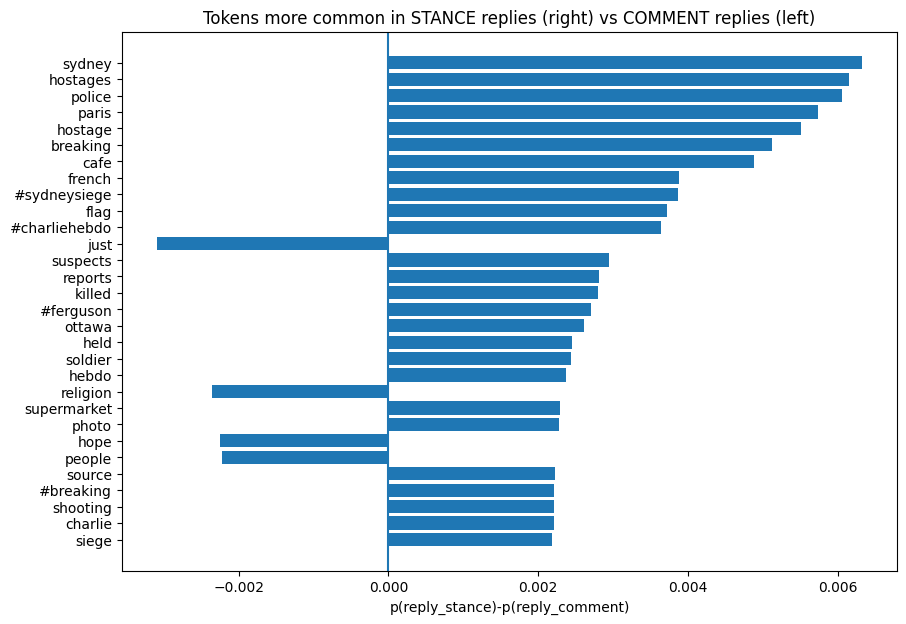

In [ ]:
# ============================================================
#  Token distribution comparisons
#  Source, Reply (S/D/Q), Comment (C)
# ============================================================

from collections import Counter
import math

STANCE_SET = {"S","D","Q"}
COMMENT_SET = {"C"}

def token_counts(df: pd.DataFrame, text_col: str) -> Counter:
    c = Counter()
    for s in df[text_col].fillna("").astype(str):
        c.update(tokenize(s))
    return c

def normalize_counter(c: Counter) -> dict:
    total = sum(c.values())
    if total == 0:
        return {}
    return {k: v/total for k,v in c.items()}

def js_divergence(p: dict, q: dict, eps=1e-12) -> float:
    # Jensen–Shannon divergence (base-2)
    keys = set(p) | set(q)
    def get(d, k): return d.get(k, 0.0)
    m = {k: 0.5*(get(p,k)+get(q,k)) for k in keys}
    def kl(a, b):
        s = 0.0
        for k in keys:
            ak = get(a,k)
            if ak > 0:
                bk = get(b,k) + eps
                s += ak * math.log2(ak / bk)
        return s
    return 0.5*kl(p,m) + 0.5*kl(q,m)

def compare_distributions(df_a: pd.DataFrame, df_b: pd.DataFrame, col_a: str, col_b: str,
                          name_a: str, name_b: str, top_k=20, min_count=10):
    ca = token_counts(df_a, col_a)
    cb = token_counts(df_b, col_b)
    pa = normalize_counter(ca)
    pb = normalize_counter(cb)
    keys = set(pa) | set(pb)

    keys = [k for k in keys if (ca.get(k,0) + cb.get(k,0)) >= min_count]

    diffs = []
    for k in keys:
        diffs.append((k, pa.get(k,0.0) - pb.get(k,0.0), ca.get(k,0), cb.get(k,0)))
    diffs.sort(key=lambda x: abs(x[1]), reverse=True)
    out = pd.DataFrame(diffs[:top_k], columns=["token", f"p({name_a})-p({name_b})", f"count_{name_a}", f"count_{name_b}"])
    return out, js_divergence(pa, pb)

# Split: stance / comment
stance_df  = train_df[train_df[LABEL_COL].isin(list(STANCE_SET))].reset_index(drop=True)
comment_df = train_df[train_df[LABEL_COL].isin(list(COMMENT_SET))].reset_index(drop=True)

print("Counts:", "stance replies:", len(stance_df), "| comment replies:", len(comment_df))


diff_stance, js_stance = compare_distributions(
    stance_df, stance_df, SOURCE_COL, REPLY_COL,
    name_a="source_stance", name_b="reply_stance",
    top_k=25, min_count=10
)
print(f"JS(source vs reply | stance) = {js_stance:.4f}")
display(diff_stance)


diff_comment, js_comment = compare_distributions(
    comment_df, comment_df, SOURCE_COL, REPLY_COL,
    name_a="source_comment", name_b="reply_comment",
    top_k=25, min_count=10
)
print(f"JS(source vs reply | comment) = {js_comment:.4f}")
display(diff_comment)


diff_reply_sc, js_reply_sc = compare_distributions(
    stance_df, comment_df, REPLY_COL, REPLY_COL,
    name_a="reply_stance", name_b="reply_comment",
    top_k=30, min_count=10
)
print(f"JS(reply stance vs reply comment) = {js_reply_sc:.4f}")
display(diff_reply_sc)

def plot_signed_diffs(df_diff: pd.DataFrame, diff_col: str, title: str):
    tmp = df_diff.copy()
    tmp = tmp.iloc[::-1] 
    plt.figure(figsize=(10, 7))
    plt.barh(tmp["token"], tmp[diff_col])
    plt.axvline(0)
    plt.title(title)
    plt.xlabel(diff_col)
    plt.show()

plot_signed_diffs(diff_reply_sc, "p(reply_stance)-p(reply_comment)",
                  "Tokens more common in STANCE replies (right) vs COMMENT replies (left)")


In [ ]:
def cue_tokens_from_top(top_uni_df: pd.DataFrame, label: str, k=20):
    sub = top_uni_df[top_uni_df["label"] == label].sort_values("rank").head(k)
    return list(sub["ngram"].values)

deny_cues  = cue_tokens_from_top(top_uni, "D", k=20)
query_cues = cue_tokens_from_top(top_uni, "Q", k=20)
supp_cues  = cue_tokens_from_top(top_uni, "S", k=20)
comm_cues  = cue_tokens_from_top(top_uni, "C", k=20)

print("Likely DENY cues (from top unigrams):", deny_cues)
print("Likely QUERY cues (from top unigrams):", query_cues)
print("Likely SUPPORT cues (from top unigrams):", supp_cues)
print("Likely COMMENT cues (from top unigrams):", comm_cues)



Likely DENY cues (from top unigrams): ['not', 'no', 'flag', "don't", 'just', 'like', 'what', "that's", 'news', 'isis', 'police', '#ferguson', 'said', 'know', 'facts', 'how', 'shot', 'islamic', 'did', 'who']
Likely QUERY cues (from top unigrams): ['what', 'why', 'not', 'no', 'police', 'how', 'did', 'does', 'source', 'where', 'sydney', 'right', 'just', 'know', "didn't", 'killed', 'tell', 'brown', 'who', 'say']
Likely SUPPORT cues (from top unigrams): ['police', 'hostages', 'paris', 'hostage', 'sydney', 'breaking', 'cafe', '#charliehebdo', '#ferguson', '#sydneysiege', 'killed', 'french', 'not', 'shooting', 'shot', 'dead', 'news', 'parliament', 'ottawa', 'held']
Likely COMMENT cues (from top unigrams): ['not', 'no', 'what', 'just', 'police', 'people', "don't", 'like', 'why', 'know', 'hostages', '#ferguson', 'shot', 'when', 'who', 'hostage', 'news', 'good', "that's", 'think']

Tip: in your write-up, connect these to stance behavior, e.g.:
- Deny: negation/falsehood markers, debunking terms,

## 1(b)

In [ ]:
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer

def lda_vectorizer(min_df=5, max_df=0.6, max_features=20000):
    return CountVectorizer(
        tokenizer=lambda s: tokenize(s),
        preprocessor=lambda s: s,
        token_pattern=None,
        lowercase=False,
        min_df=min_df,
        max_df=max_df,
        max_features=max_features
    )

stance_texts  = stance_df[REPLY_COL].fillna("").astype(str).tolist()
comment_texts = comment_df[REPLY_COL].fillna("").astype(str).tolist()

print("Docs - stance:", len(stance_texts), "comment:", len(comment_texts))

vec_stance = lda_vectorizer(min_df=8, max_df=0.6)
X_stance = vec_stance.fit_transform(stance_texts)
vocab_stance = vec_stance.get_feature_names_out()

vec_comment = lda_vectorizer(min_df=5, max_df=0.6)
X_comment = vec_comment.fit_transform(comment_texts)
vocab_comment = vec_comment.get_feature_names_out()

print("Vocab size - stance:", len(vocab_stance), "comment:", len(vocab_comment))
print("X shapes - stance:", X_stance.shape, "comment:", X_comment.shape)


Docs - stance: 1278 comment: 2291
Vocab size - stance: 234 comment: 658
X shapes - stance: (1278, 234) comment: (2291, 658)



LDA topics on STANCE replies {S,D,Q}
Topic 0: what, why, not, did, does, police, no, stop, report, tell, know, when
Topic 1: #sydneysiege, sydney, hostages, don't, cafe, siege, people, yes, live, statement, updates, escaped
Topic 2: shot, parliament, ottawa, soldier, who, war, hill, memorial, shots, shooting, fired, inside
Topic 3: not, flag, news, like, islamic, just, isis, hostage, sydney, hostages, breaking, cafe
Topic 4: #ferguson, police, reports, robbery, brown, think, shooting, say, cops, lie, not, 11
Topic 5: no, #charliehebdo, dead, said, attack, michael, right, cop, video, need, confirmed, oh
Topic 6: hostage, police, killed, sydney, charlie, hebdo, situation, how, where, suspects, held, #charliehebdo
Topic 7: french, paris, photo, hostages, supermarket, #afp, alps, germanwings, freed, samson, thomas, jewish

LDA topics on COMMENT replies {C}
Topic 0: safe, free, help, today, store, #germanwings, breaking, stay, ottawa, french, that's, make
Topic 1: police, not, good, people

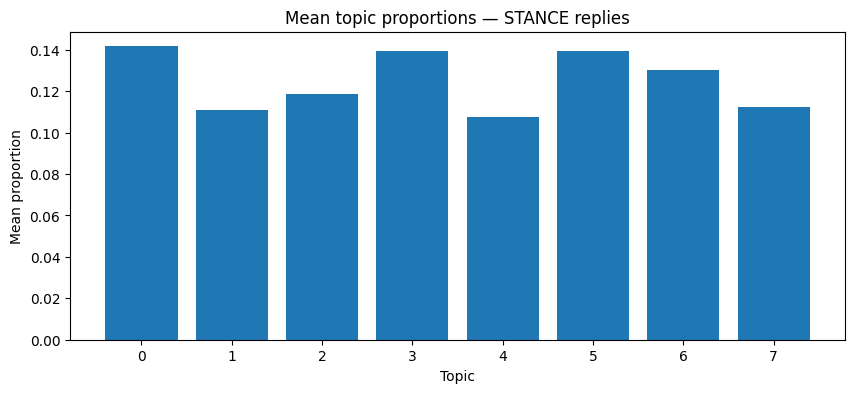

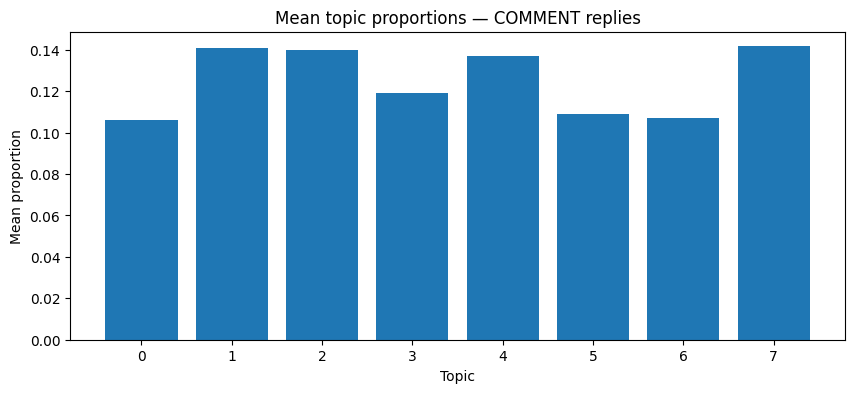

In [ ]:
def fit_lda(X, n_topics=8, max_iter=25, random_state=42):
    lda = LatentDirichletAllocation(
        n_components=n_topics,
        max_iter=max_iter,
        learning_method="batch",
        random_state=random_state,
        evaluate_every=-1,
        n_jobs=-1
    )
    lda.fit(X)
    return lda

def top_words_per_topic(lda, vocab, top_n=12):
    topic_words = []
    for k, topic in enumerate(lda.components_):
        top_idx = np.argsort(topic)[::-1][:top_n]
        topic_words.append((k, [(vocab[i], float(topic[i])) for i in top_idx]))
    return topic_words

def display_topics(topic_words, title):
    print("\n" + "="*len(title))
    print(title)
    print("="*len(title))
    for k, words in topic_words:
        w_only = [w for w,_ in words]
        print(f"Topic {k}: " + ", ".join(w_only))


N_TOPICS_STANCE  = 8
N_TOPICS_COMMENT = 8

lda_stance  = fit_lda(X_stance,  n_topics=N_TOPICS_STANCE,  max_iter=25, random_state=42)
lda_comment = fit_lda(X_comment, n_topics=N_TOPICS_COMMENT, max_iter=25, random_state=42)

topics_stance  = top_words_per_topic(lda_stance,  vocab_stance,  top_n=12)
topics_comment = top_words_per_topic(lda_comment, vocab_comment, top_n=12)

display_topics(topics_stance,  "LDA topics on STANCE replies {S,D,Q}")
display_topics(topics_comment, "LDA topics on COMMENT replies {C}")

def topic_prevalence(lda, X):
    doc_topic = lda.transform(X)
    return doc_topic.mean(axis=0)

prev_stance  = topic_prevalence(lda_stance, X_stance)
prev_comment = topic_prevalence(lda_comment, X_comment)

plt.figure(figsize=(10,4))
plt.bar(range(len(prev_stance)), prev_stance)
plt.title("Mean topic proportions — STANCE replies")
plt.xlabel("Topic")
plt.ylabel("Mean proportion")
plt.show()

plt.figure(figsize=(10,4))
plt.bar(range(len(prev_comment)), prev_comment)
plt.title("Mean topic proportions — COMMENT replies")
plt.xlabel("Topic")
plt.ylabel("Mean proportion")
plt.show()

In [ ]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

WC_STOPWORDS = set(ENGLISH_STOP_WORDS)

# remove twitter words
WC_STOPWORDS |= {"rt", "amp", "@user"}

# also remove
WC_STOPWORDS |= {
    "it's", "its", "im", "i'm", "dont", "don't", "ive", "i've",
    "like", "just", "really", "much", "also", "yes"
}

# Remove questions
WC_STOPWORDS |= {
    "why", "how", "where", "when", "what", "who",
    "did", "does", "do", "is", "are", "was", "were", "be", "been", "being",
    "can", "could", "would", "should", "may", "might", "must"
}

# Remove negation
WC_STOPWORDS |= {"no", "not", "never", "n't"}

def tokenize_for_wordcloud(s: str) -> list[str]:
    """
    Tokenization used ONLY for wordclouds.
    Keeps the same basic normalization but applies WC_STOPWORDS.
    """
    s = normalize_text(s)
    toks = TOKEN_RE.findall(s)
    cleaned = []
    for t in toks:
        tl = t.lower()
        if tl in WC_STOPWORDS:
            continue
        if len(tl) <= 2:
            continue
        cleaned.append(tl)
    return cleaned

print("WordCloud stopwords size:", len(WC_STOPWORDS))


WordCloud stopwords size: 335


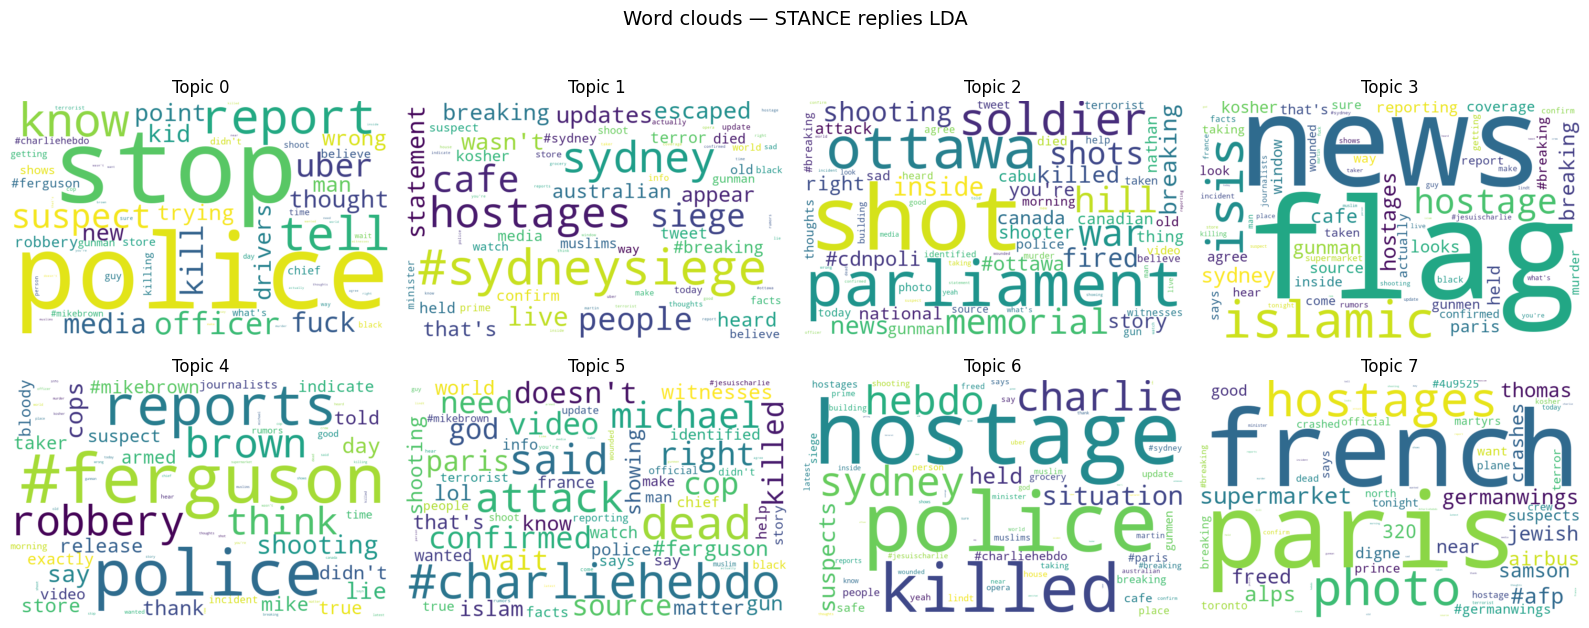

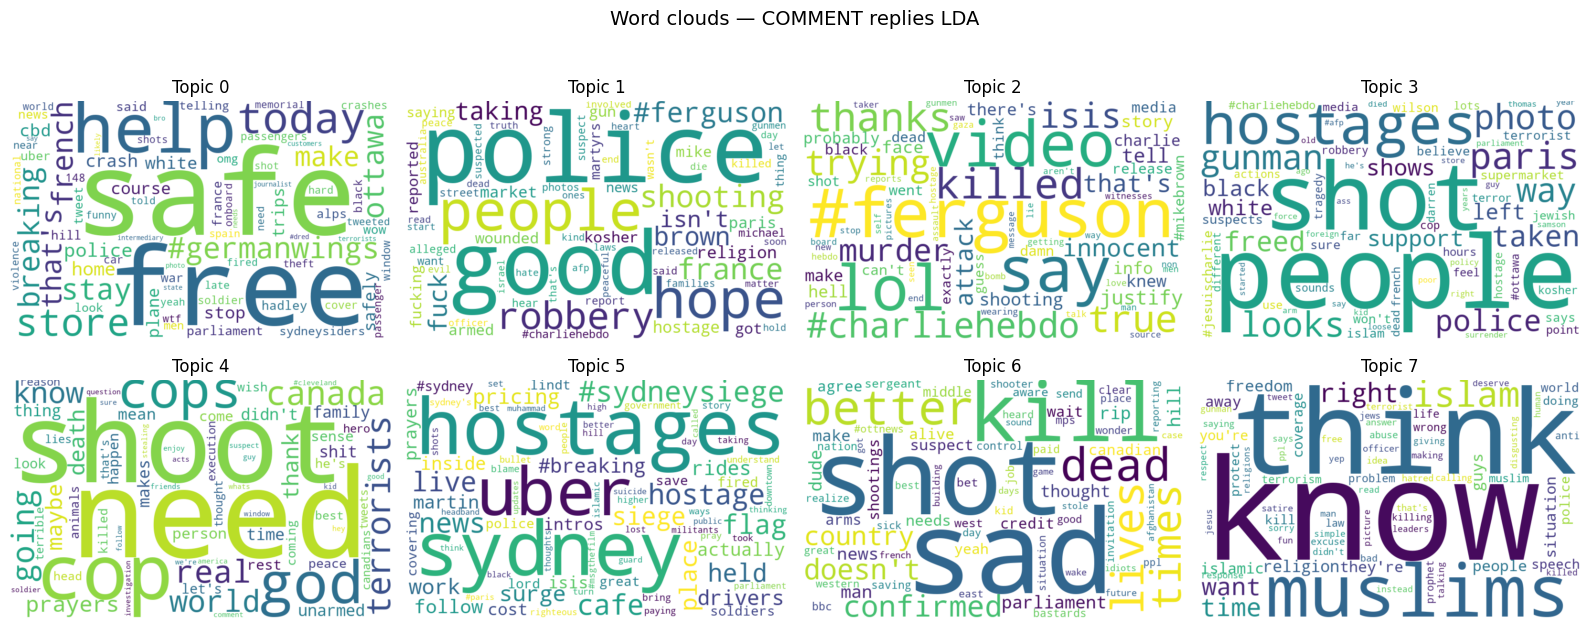

In [ ]:
try:
    from wordcloud import WordCloud
except ImportError:
    import sys
    !{sys.executable} -m pip -q install wordcloud
    from wordcloud import WordCloud

def topic_wordclouds(lda, vocab, n_top=60, n_cols=4, title=""):
    n_topics = lda.n_components
    n_rows = int(np.ceil(n_topics / n_cols))
    plt.figure(figsize=(4*n_cols, 3.2*n_rows))

    for k in range(n_topics):
        weights = lda.components_[k]
        top_idx = np.argsort(weights)[::-1][:n_top]

        freqs = {vocab[i]: float(weights[i]) for i in top_idx}

        freqs = {w: wt for w, wt in freqs.items() if w not in WC_STOPWORDS and len(w) > 2}

        wc = WordCloud(
            width=800,
            height=500,
            background_color="white",
            stopwords=WC_STOPWORDS
        ).generate_from_frequencies(freqs)

        ax = plt.subplot(n_rows, n_cols, k+1)
        ax.imshow(wc, interpolation="bilinear")
        ax.set_title(f"Topic {k}")
        ax.axis("off")

    plt.suptitle(title, y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

topic_wordclouds(lda_stance, vocab_stance, n_top=80, n_cols=4, title="Word clouds — STANCE replies LDA")
topic_wordclouds(lda_comment, vocab_comment, n_top=80, n_cols=4, title="Word clouds — COMMENT replies LDA")


          count      mean       std       min       25%       50%       75%  \
group                                                                         
comment  2291.0  1.209228  0.409848  0.336041  0.951368  1.172105  1.530239   
stance   1278.0  1.251096  0.441668  0.377778  0.951267  1.255013  1.536650   

              max  
group              
comment  2.079442  
stance   2.079442  


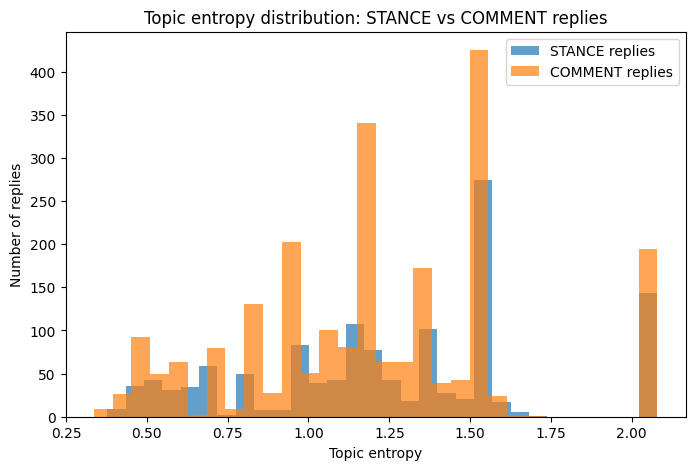

/var/folders/b1/4l3hp6gj3mbbwc4py3ny7__80000gn/T/ipykernel_2200/4179897016.py:54: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([entropy_stance, entropy_comment], labels=["STANCE", "COMMENT"])


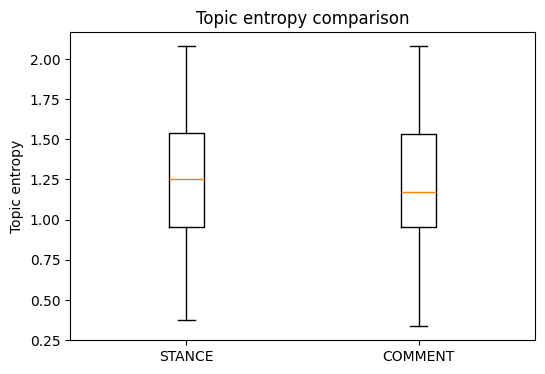

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def topic_entropy(theta, eps=1e-12):
    theta = np.clip(theta, eps, 1.0)
    return -np.sum(theta * np.log(theta), axis=1)


theta_stance  = lda_stance.transform(X_stance)
theta_comment = lda_comment.transform(X_comment)


entropy_stance  = topic_entropy(theta_stance)
entropy_comment = topic_entropy(theta_comment)

# Summary
entropy_df = pd.DataFrame({
    "group": ["stance"] * len(entropy_stance) + ["comment"] * len(entropy_comment),
    "entropy": np.concatenate([entropy_stance, entropy_comment])
})

print(entropy_df.groupby("group")["entropy"].describe())


# Visuals

plt.figure(figsize=(8, 5))
plt.hist(entropy_stance, bins=30, alpha=0.7, label="STANCE replies")
plt.hist(entropy_comment, bins=30, alpha=0.7, label="COMMENT replies")
plt.xlabel("Topic entropy")
plt.ylabel("Number of replies")
plt.title("Topic entropy distribution: STANCE vs COMMENT replies")
plt.legend()
plt.show()

plt.figure(figsize=(6, 4))
plt.boxplot([entropy_stance, entropy_comment], labels=["STANCE", "COMMENT"])
plt.ylabel("Topic entropy")
plt.title("Topic entropy comparison")
plt.show()
